In [2]:
# Importer les bibliothèques nécessaires
import pandas as pd
import plotly.express as px
import requests



In [3]:

#%% 2. Charger le fichier CSV
df = pd.read_csv("C:/Users/Dell/Desktop/projet dev web/dvf_cleaned.csv")

print(" Fichier chargé avec succès !")
print("Voici les colonnes du fichier :")
print(df.columns)
print("\nAperçu des 5 premières lignes :")
print(df.head())


 Fichier chargé avec succès !
Voici les colonnes du fichier :
Index(['valeur_fonciere', 'surface_reelle_bati', 'prix_m2', 'code_departement',
       'nom_commune', 'type_local'],
      dtype='object')

Aperçu des 5 premières lignes :
   valeur_fonciere  surface_reelle_bati  prix_m2  code_departement  \
0           171958                   91     3625                69   
1           196867                   69     3729                13   
2           181932                  114     7700                69   
3           415838                  109     2597                69   
4           309178                  138     4060                 6   

  nom_commune   type_local  
0       Paris  Appartement  
1   Marseille  Appartement  
2        Lyon       Maison  
3        Nice  Appartement  
4    Bordeaux       Maison  


In [4]:
#%%  3. Préparer les données
df.columns = df.columns.str.lower()

# Trouver la colonne de surface
if "surface_reelle_bati" in df.columns:
    surface_col = "surface_reelle_bati"
elif "surface" in df.columns:
    surface_col = "surface"
else:
    print("⚠️ Colonne de surface introuvable.")
    surface_col = None

# Calcul du prix au m²
if "prix_m2" not in df.columns and surface_col:
    df["prix_m2"] = df["valeur_fonciere"] / df[surface_col]

# Nettoyage
if surface_col:
    df = df.dropna(subset=["prix_m2", surface_col])
    df = df[df["prix_m2"] < 20000]

print(f"\n Données prêtes : {len(df)} lignes.")
print(f" Colonne de surface utilisée : {surface_col}")


 Données prêtes : 100 lignes.
 Colonne de surface utilisée : surface_reelle_bati


In [5]:
#%% 4. Graphique 1 - Distribution des prix au m²
fig = px.histogram(
    df,
    x="prix_m2",
    nbins=40,
    title="Distribution des prix au m²",
    color_discrete_sequence=["#4C78A8"],
    labels={"prix_m2": "Prix au m² (€)"}
)
fig.update_layout(template="plotly_white", width=1000, height=600)

# 👉 SAUVEGARDE GRAPHIQUE 1
fig.write_image("graph_1_histogramme_prix_m2.png")

fig.show()

In [6]:
#%% 5. Graphique 2 - Relation entre surface et prix
if surface_col:
    fig = px.scatter(
        df,
        x=surface_col,
        y="prix_m2",
        title="Relation entre surface et prix au m²",
        labels={surface_col: "Surface (m²)", "prix_m2": "Prix au m² (€)"},
        color="prix_m2",
        color_continuous_scale="Viridis"
    )
    fig.update_layout(template="plotly_white", width=1000, height=600)

    # 👉 SAUVEGARDE GRAPHIQUE 2
    fig.write_image("graph_2_relation_surface_prix.png")

    fig.show()

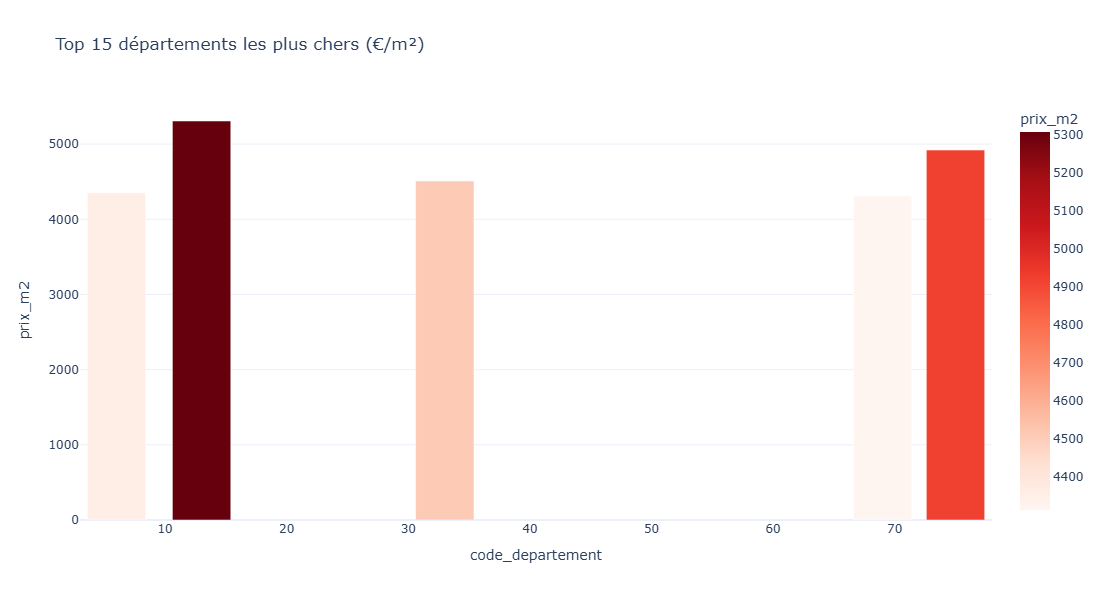

In [7]:
#%% 6. Graphique 3 - Classement des départements
if "code_departement" in df.columns:
    prix_par_dept = (
        df.groupby("code_departement")["prix_m2"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    fig = px.bar(
        prix_par_dept.head(15),
        x="code_departement",
        y="prix_m2",
        title="Top 15 départements les plus chers (€/m²)",
        color="prix_m2",
        color_continuous_scale="Reds"
    )
    fig.update_layout(template="plotly_white", width=1000, height=600)

    # 👉 SAUVEGARDE GRAPHIQUE 3
    fig.write_image("graph_3_departements_chers.png")

    fig.show()


In [9]:
#%% 7. Graphique 4 - Carte interactive des prix
if "code_departement" in df.columns:
    url_geo = "https://france-geojson.gregoiredavid.fr/repo/departements.geojson"
    geojson = requests.get(url_geo).json()

    prix_par_dept = (
        df.groupby("code_departement")["prix_m2"]
        .mean()
        .reset_index()
        .rename(columns={"code_departement": "code"})
    )

    fig = px.choropleth_mapbox(
        prix_par_dept,
        geojson=geojson,
        locations="code",
        featureidkey="properties.code",
        color="prix_m2",
        color_continuous_scale="YlOrRd",
        mapbox_style="carto-positron",
        center={"lat": 46.5, "lon": 2.5},
        zoom=4.5,
        title="Carte des prix immobiliers moyens par département (€/m²)",
        opacity=0.8
    )
    fig.update_layout(width=1000, height=700, margin={"r":0,"t":40,"l":0,"b":0})

    # 👉 SAUVEGARDE GRAPHIQUE 4
    fig.write_image("graph_4_carte_prix_departements.png")

    fig.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_9892\3188469888.py:13: DeprecationWarning:

*choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

Resorting to unclean kill browser.


RuntimeError: Couldn't close or kill browser subprocess